# Elasticity Identification Diagnostics

This notebook investigates two potential issues with elasticity estimates:

1. **Limited Price Variation**: If prices don't vary enough within products, elasticity is poorly identified
2. **Endogeneity**: If sellers raise prices when demand is high, estimates are biased toward zero

**Key findings from baseline models:**
- Per-product log-log: median elasticity = -0.27, only 57.5% negative
- Pooled log-log: coefficient = -0.49
- Two-head NN: elasticity = -0.55

These are lower than typical retail elasticities (-1 to -3), suggesting identification issues.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Statistical tools
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# For IV regression
try:
    from linearmodels.iv import IV2SLS
    HAS_LINEARMODELS = True
except ImportError:
    print("linearmodels not installed. Run: pip install linearmodels")
    HAS_LINEARMODELS = False

# Paths
ROOT = Path("..")
DATA_DIR = ROOT / "data/processed"
TABLES_DIR = ROOT / "tables"
FIGURES_DIR = ROOT / "docs/figures"
DOCS_DIR = ROOT / "docs"

# Ensure directories exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

np.random.seed(42)

print("Setup complete!")

Setup complete!


In [2]:
# Load panel data
panel = pd.read_csv(DATA_DIR / "panel.csv")
panel["week"] = pd.to_datetime(panel["week"])

print(f"Panel shape: {panel.shape}")
print(f"Products: {panel['product_id'].nunique()}")
print(f"Weeks: {panel['week'].nunique()}")
print(f"\nSplit distribution:")
print(panel['split'].value_counts())

Panel shape: (17970, 43)
Products: 1218
Weeks: 89

Split distribution:
split
train    11708
val       3392
test      2870
Name: count, dtype: int64


In [3]:
# Compute per-product elasticities (replicating from baselines)
from sklearn.linear_model import LinearRegression

# Filter to usable products
usable_products = panel[panel["usable_for_elasticity"] == 1]["product_id"].unique()
print(f"Usable products for elasticity: {len(usable_products)}")

# Fit per-product log-log regressions
per_product_results = []

for product_id in usable_products:
    product_data = panel[panel["product_id"] == product_id]
    train_data = product_data[product_data["split"] == "train"]
    
    if len(train_data) < 3:
        continue
    
    X = np.log(train_data["r_clipped"].values).reshape(-1, 1)
    y = train_data["y"].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Compute R² and standard error
    y_pred = model.predict(X)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Standard error of coefficient
    n = len(y)
    if n > 2 and ss_tot > 0:
        mse = ss_res / (n - 2)
        var_x = np.var(X, ddof=1)
        se_coef = np.sqrt(mse / (var_x * (n - 1))) if var_x > 0 else np.nan
    else:
        se_coef = np.nan
    
    # Price variation stats
    r_values = train_data["r_clipped"].values
    price_span = r_values.max() - r_values.min()
    price_cv = r_values.std() / r_values.mean() if r_values.mean() > 0 else 0
    
    per_product_results.append({
        "product_id": product_id,
        "elasticity": model.coef_[0],
        "intercept": model.intercept_,
        "r2": r2,
        "se_coef": se_coef,
        "n_obs": n,
        "price_span": price_span,
        "price_cv": price_cv,
        "price_mean": r_values.mean(),
        "price_std": r_values.std(),
        "category": train_data["product_category_name_english"].iloc[0]
    })

elasticity_df = pd.DataFrame(per_product_results)
print(f"\nComputed elasticities for {len(elasticity_df)} products")
print(f"\nElasticity statistics:")
print(elasticity_df["elasticity"].describe())

Usable products for elasticity: 812

Computed elasticities for 812 products

Elasticity statistics:
count    812.000000
mean      -0.674059
std        3.965125
min      -42.880053
25%       -1.604854
50%       -0.271974
75%        0.576368
max       17.772916
Name: elasticity, dtype: float64


---
# Part 1: Price Variation Analysis

If prices don't vary enough within products, elasticity estimates will be:
- Imprecise (high standard errors)
- Potentially biased by noise
- Dominated by between-product variation rather than within-product

## 1.1 Descriptive Statistics of Price Variation

In [4]:
# Price span statistics
print("=" * 60)
print("PRICE VARIATION STATISTICS")
print("=" * 60)

print("\n--- Price Span (max(r) - min(r)) ---")
print(elasticity_df["price_span"].describe())

print("\n--- Coefficient of Variation (std/mean) ---")
print(elasticity_df["price_cv"].describe())

# Thresholds
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30]
print("\n--- Products by Price Span Threshold ---")
for t in thresholds:
    n_below = (elasticity_df["price_span"] < t).sum()
    pct_below = n_below / len(elasticity_df) * 100
    print(f"  span < {t*100:.0f}%: {n_below} products ({pct_below:.1f}%)")

PRICE VARIATION STATISTICS

--- Price Span (max(r) - min(r)) ---
count    812.000000
mean       0.191092
std        0.118200
min        0.020107
25%        0.095431
50%        0.166435
75%        0.267755
max        0.498032
Name: price_span, dtype: float64

--- Coefficient of Variation (std/mean) ---
count    812.000000
mean       0.070582
std        0.045978
min        0.005384
25%        0.035209
50%        0.060686
75%        0.096693
max        0.248006
Name: price_cv, dtype: float64

--- Products by Price Span Threshold ---
  span < 5%: 63 products (7.8%)
  span < 10%: 214 products (26.4%)
  span < 15%: 374 products (46.1%)
  span < 20%: 483 products (59.5%)
  span < 30%: 647 products (79.7%)


In [5]:
# Weighted within-product vs between-product decomposition of weekly avg_price
print("\n--- Variance Decomposition (weighted SS on avg_price) ---")

# Restrict to usable products in the train split
train_panel = panel[(panel["split"] == "train") & (panel["usable_for_elasticity"] == 1)].copy()
print(f"Usable products:         {train_panel['product_id'].nunique()}")
print(f"Train rows:              {len(train_panel)}")

grand_mean = train_panel["avg_price"].mean()
group_means = train_panel.groupby("product_id")["avg_price"].transform("mean")
group_stats = train_panel.groupby("product_id")["avg_price"].agg(["mean", "count"])

ss_total = ((train_panel["avg_price"] - grand_mean) ** 2).sum()
ss_within = ((train_panel["avg_price"] - group_means) ** 2).sum()
ss_between = (group_stats["count"] * (group_stats["mean"] - grand_mean) ** 2).sum()
within_share_pct = ss_within / ss_total * 100
between_share_pct = ss_between / ss_total * 100

print(f"Total SS of avg_price:   {ss_total:.6f}")
print(f"Between-product SS:      {ss_between:.6f} ({between_share_pct:.1f}%)")
print(f"Within-product SS:       {ss_within:.6f} ({within_share_pct:.1f}%)")
print(f"SS identity check:       {(ss_total - ss_between - ss_within):.6e}")


--- Variance Decomposition (weighted SS on avg_price) ---
Usable products:         812
Train rows:              9250
Total SS of avg_price:   121944906.344091
Between-product SS:      120677226.428208 (99.0%)
Within-product SS:       1267679.915883 (1.0%)
SS identity check:       -3.492460e-09


## 1.2 Visualizations

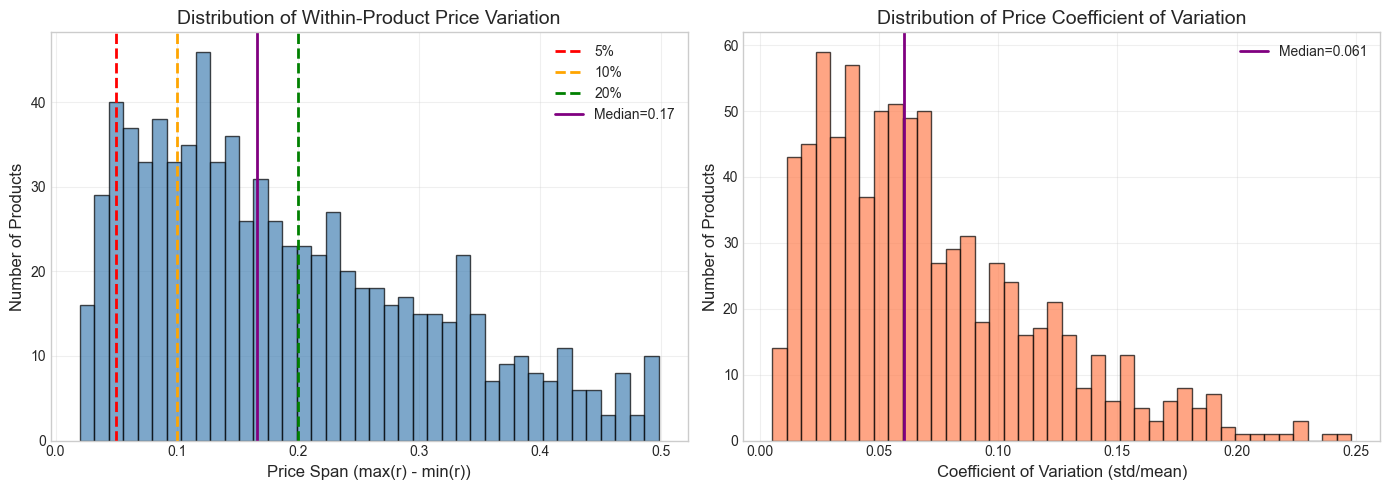

Saved: ../docs/figures/price_span_distribution.png


In [6]:
# Figure 1: Price span distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of price span
ax = axes[0]
ax.hist(elasticity_df["price_span"], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='5%')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=2, label='10%')
ax.axvline(x=0.20, color='green', linestyle='--', linewidth=2, label='20%')
ax.axvline(x=elasticity_df["price_span"].median(), color='purple', linestyle='-', 
           linewidth=2, label=f'Median={elasticity_df["price_span"].median():.2f}')
ax.set_xlabel('Price Span (max(r) - min(r))', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_title('Distribution of Within-Product Price Variation', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Histogram of CV
ax = axes[1]
ax.hist(elasticity_df["price_cv"], bins=40, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(x=elasticity_df["price_cv"].median(), color='purple', linestyle='-', 
           linewidth=2, label=f'Median={elasticity_df["price_cv"].median():.3f}')
ax.set_xlabel('Coefficient of Variation (std/mean)', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_title('Distribution of Price Coefficient of Variation', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_span_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'price_span_distribution.png'}")

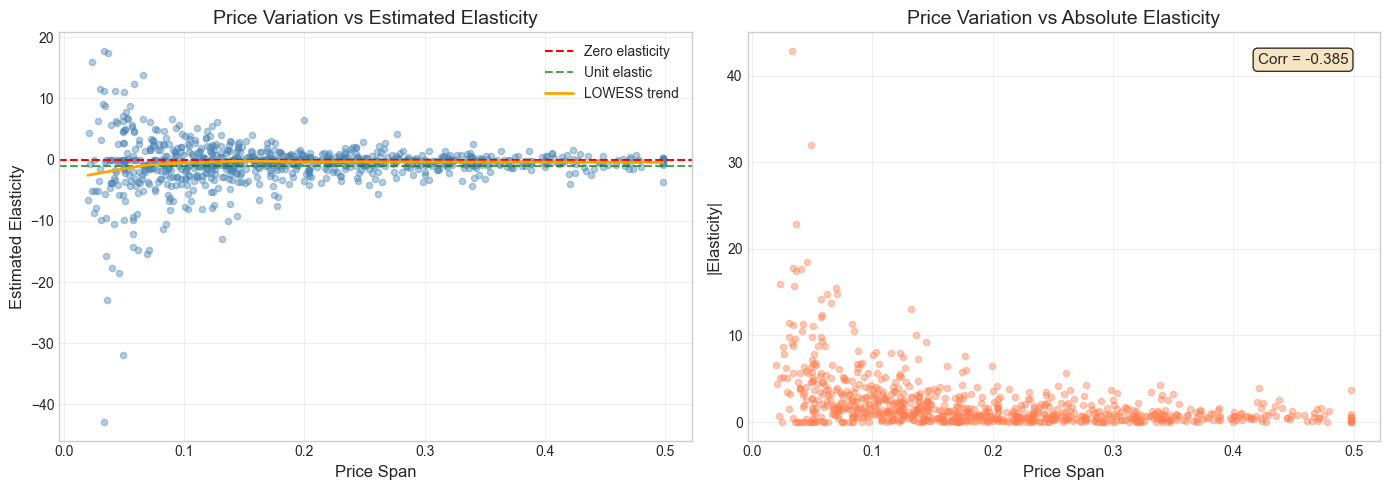

Saved: ../docs/figures/price_span_vs_elasticity.png


In [19]:
# Figure 2: Price span vs Elasticity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: span vs elasticity
ax = axes[0]
ax.scatter(elasticity_df["price_span"], elasticity_df["elasticity"], 
           alpha=0.4, s=20, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero elasticity')
ax.axhline(y=-1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Unit elastic')
ax.set_xlabel('Price Span', fontsize=12)
ax.set_ylabel('Estimated Elasticity', fontsize=12)
ax.set_title('Price Variation vs Estimated Elasticity', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Add lowess trend
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    # Sort by price_span for smooth line
    sorted_idx = elasticity_df["price_span"].argsort()
    x_sorted = elasticity_df["price_span"].values[sorted_idx]
    y_sorted = elasticity_df["elasticity"].values[sorted_idx]
    lowess_result = lowess(y_sorted, x_sorted, frac=0.3)
    ax.plot(lowess_result[:, 0], lowess_result[:, 1], 'orange', linewidth=2, label='LOWESS trend')
    ax.legend()
except:
    pass

# Scatter: span vs |elasticity|
ax = axes[1]
ax.scatter(elasticity_df["price_span"], np.abs(elasticity_df["elasticity"]), 
           alpha=0.4, s=20, color='coral')
ax.set_xlabel('Price Span', fontsize=12)
ax.set_ylabel('|Elasticity|', fontsize=12)
ax.set_title('Price Variation vs Absolute Elasticity', fontsize=14)
ax.grid(alpha=0.3)

# Correlation
corr = elasticity_df["price_span"].corr(np.abs(elasticity_df["elasticity"]))
ax.text(0.95, 0.95, f'Corr = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_span_vs_elasticity.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'price_span_vs_elasticity.png'}")

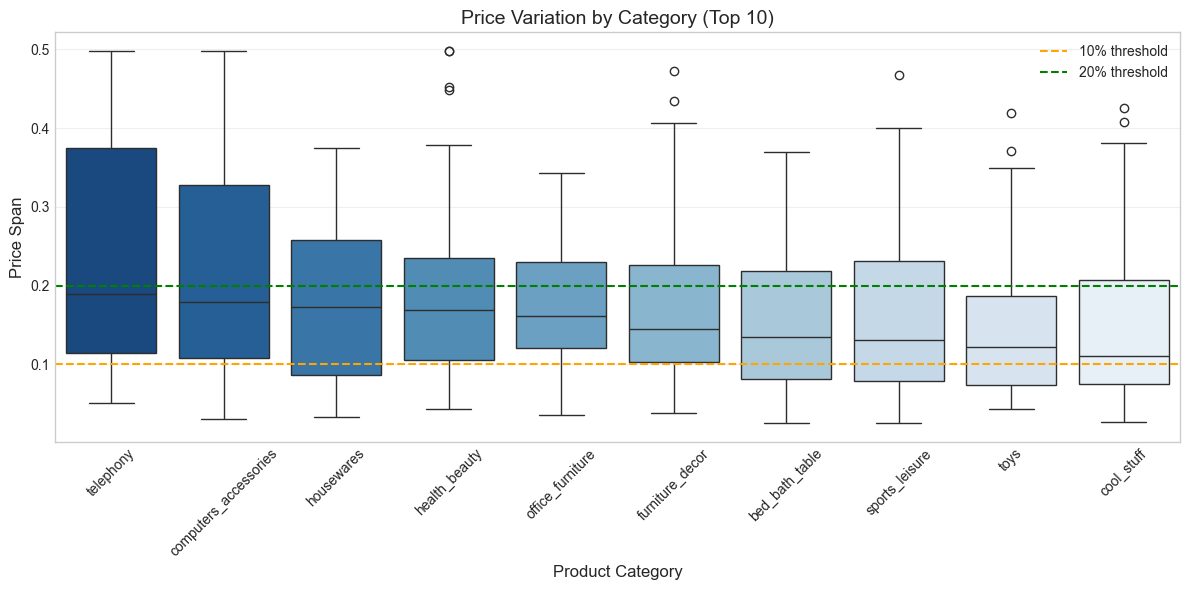

In [7]:
# Figure 3: Price variation by category (top 10)
top_categories = elasticity_df["category"].value_counts().head(10).index.tolist()
plot_df = elasticity_df[elasticity_df["category"].isin(top_categories)]

fig, ax = plt.subplots(figsize=(12, 6))

# Order by median price span
category_order = plot_df.groupby("category")["price_span"].median().sort_values(ascending=False).index

sns.boxplot(data=plot_df, x="category", y="price_span", order=category_order, 
            palette="Blues_r", ax=ax)
ax.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='10% threshold')
ax.axhline(y=0.20, color='green', linestyle='--', linewidth=1.5, label='20% threshold')

ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Price Span', fontsize=12)
ax.set_title('Price Variation by Category (Top 10)', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_span_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Identification Quality by Price Variation

In [8]:
# Analyze model quality by price span groups
print("=" * 60)
print("MODEL QUALITY BY PRICE SPAN GROUP")
print("=" * 60)

# Create price span groups
elasticity_df["span_group"] = pd.cut(
    elasticity_df["price_span"],
    bins=[0, 0.05, 0.10, 0.20, 1.0],
    labels=["<5%", "5-10%", "10-20%", ">20%"]
)

# Summary by group
group_stats = elasticity_df.groupby("span_group", observed=True).agg({
    "product_id": "count",
    "elasticity": ["mean", "median", "std"],
    "r2": ["mean", "median"],
    "se_coef": ["mean", "median"],
    "n_obs": "mean"
}).round(3)

# Flatten column names
group_stats.columns = ["_".join(col).strip("_") for col in group_stats.columns]
group_stats = group_stats.rename(columns={"product_id_count": "n_products"})

print("\n" + group_stats.to_string())

# Share of positive elasticities by group
print("\n--- Share of Positive (Wrong Sign) Elasticities ---")
for group in elasticity_df["span_group"].cat.categories:
    group_data = elasticity_df[elasticity_df["span_group"] == group]
    if len(group_data) > 0:
        pct_positive = (group_data["elasticity"] > 0).mean() * 100
        print(f"  {group}: {pct_positive:.1f}% positive")

MODEL QUALITY BY PRICE SPAN GROUP

            n_products  elasticity_mean  elasticity_median  elasticity_std  r2_mean  r2_median  se_coef_mean  se_coef_median  n_obs_mean
span_group                                                                                                                              
<5%                 63           -1.914             -0.659          10.385    0.134      0.079         7.954           5.861      11.667
5-10%              151           -0.675             -0.594           4.815    0.157      0.092         3.611           3.095      10.927
10-20%             269           -0.625             -0.259           2.685    0.147      0.067         1.933           1.582      11.346
>20%               329           -0.476             -0.256           1.288    0.145      0.073         0.981           0.857      11.590

--- Share of Positive (Wrong Sign) Elasticities ---
  <5%: 33.3% positive
  5-10%: 37.7% positive
  10-20%: 40.1% positive
  >20%: 32.2% posit

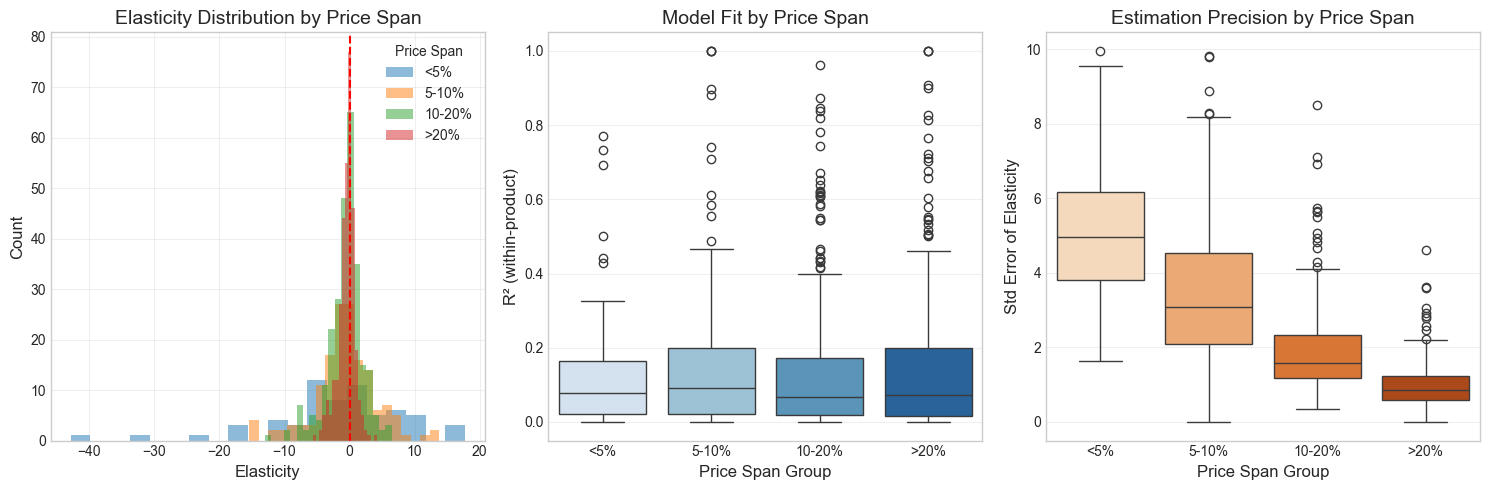

In [9]:
# Visualize quality by span group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Elasticity distribution by group
ax = axes[0]
for i, group in enumerate(elasticity_df["span_group"].cat.categories):
    group_data = elasticity_df[elasticity_df["span_group"] == group]["elasticity"]
    if len(group_data) > 0:
        ax.hist(group_data, bins=20, alpha=0.5, label=group)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Elasticity', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Elasticity Distribution by Price Span', fontsize=14)
ax.legend(title='Price Span')
ax.grid(alpha=0.3)

# 2. R² by group
ax = axes[1]
sns.boxplot(data=elasticity_df, x="span_group", y="r2", palette="Blues", ax=ax)
ax.set_xlabel('Price Span Group', fontsize=12)
ax.set_ylabel('R² (within-product)', fontsize=12)
ax.set_title('Model Fit by Price Span', fontsize=14)
ax.grid(alpha=0.3, axis='y')

# 3. SE of coefficient by group
ax = axes[2]
# Clip SE to reasonable range for visualization
plot_se = elasticity_df[elasticity_df["se_coef"].notna() & (elasticity_df["se_coef"] < 10)]
sns.boxplot(data=plot_se, x="span_group", y="se_coef", palette="Oranges", ax=ax)
ax.set_xlabel('Price Span Group', fontsize=12)
ax.set_ylabel('Std Error of Elasticity', fontsize=12)
ax.set_title('Estimation Precision by Price Span', fontsize=14)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "quality_by_price_span.png", dpi=300, bbox_inches='tight')
plt.show()

### Part 1 Summary

Key findings on price variation will be summarized here after running the cells.

---
# Part 2: Endogeneity Diagnostics

If sellers adjust prices based on demand conditions (e.g., raising prices when demand is high), then:
- OLS estimates of price elasticity are biased toward zero (attenuation bias)
- This could explain why 42.5% of products have positive elasticities (wrong sign)

**Tests:**
1. Correlation between lagged demand and current price
2. Comparison of OLS specifications with/without demand controls
3. IV regression using freight as an instrument

## 2.1 Signs of Endogeneity

In [10]:
# Check correlation between lagged demand and current price
print("=" * 60)
print("SIGNS OF ENDOGENEITY")
print("=" * 60)

train_panel = panel[panel["split"] == "train"].copy()

# Correlation: demand_lag_1 vs r
corr_lag1_r = train_panel["demand_lag_1"].corr(train_panel["r_clipped"])
corr_lag1_price = train_panel["demand_lag_1"].corr(train_panel["avg_price"])

print("\n--- Correlation: Lagged Demand vs Current Price ---")
print(f"  Corr(demand_lag_1, r):         {corr_lag1_r:.4f}")
print(f"  Corr(demand_lag_1, avg_price): {corr_lag1_price:.4f}")

# Filter to non-zero lags
nonzero_lag = train_panel[train_panel["demand_lag_1"] > 0]
corr_lag1_r_nz = nonzero_lag["demand_lag_1"].corr(nonzero_lag["r_clipped"])
print(f"  Corr(demand_lag_1, r) [lag>0]: {corr_lag1_r_nz:.4f}")

# Per-product correlation
product_corrs = []
for pid in train_panel["product_id"].unique():
    pdata = train_panel[train_panel["product_id"] == pid]
    if len(pdata) >= 5:
        corr = pdata["demand_lag_1"].corr(pdata["r_clipped"])
        if not np.isnan(corr):
            product_corrs.append(corr)

print(f"\n--- Per-Product Correlations (demand_lag_1 vs r) ---")
print(f"  Mean:   {np.mean(product_corrs):.4f}")
print(f"  Median: {np.median(product_corrs):.4f}")
print(f"  % positive: {(np.array(product_corrs) > 0).mean()*100:.1f}%")

# Share of positive elasticities
pct_positive = (elasticity_df["elasticity"] > 0).mean() * 100
print(f"\n--- Share of Positive (Wrong Sign) Elasticities ---")
print(f"  {pct_positive:.1f}% of products have positive elasticity")

SIGNS OF ENDOGENEITY

--- Correlation: Lagged Demand vs Current Price ---
  Corr(demand_lag_1, r):         -0.0483
  Corr(demand_lag_1, avg_price): -0.0317
  Corr(demand_lag_1, r) [lag>0]: -0.0483

--- Per-Product Correlations (demand_lag_1 vs r) ---
  Mean:   -0.0149
  Median: -0.0222
  % positive: 46.1%

--- Share of Positive (Wrong Sign) Elasticities ---
  36.0% of products have positive elasticity


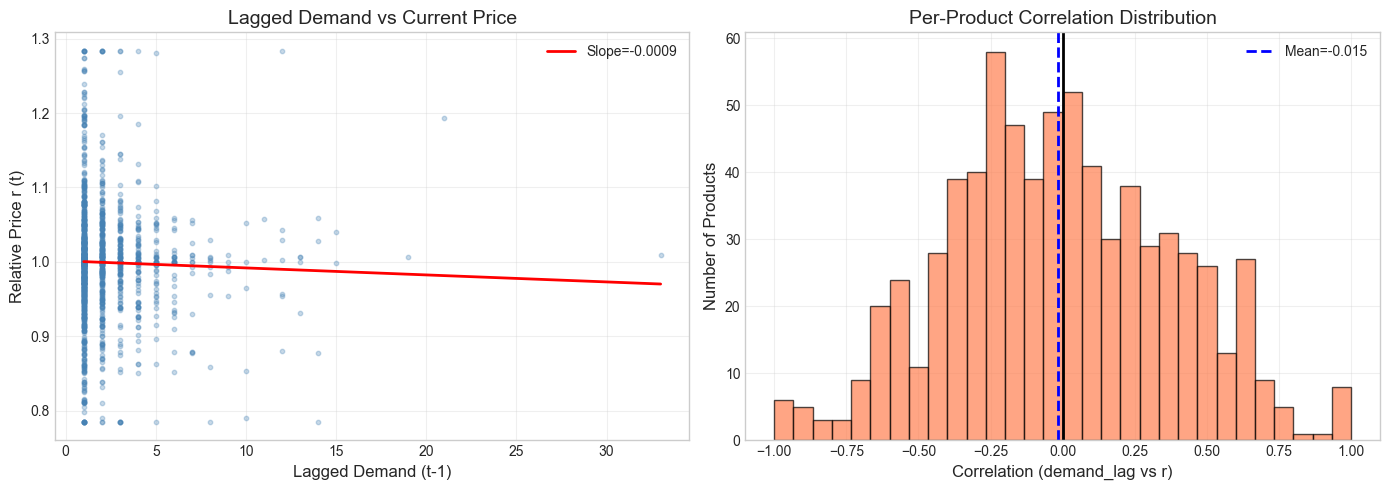

Saved: ../docs/figures/endogeneity_lag_price.png


In [11]:
# Figure: Lagged demand vs price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: demand_lag vs r (sample for visibility)
sample = train_panel.sample(min(2000, len(train_panel)), random_state=42)

ax = axes[0]
ax.scatter(sample["demand_lag_1"], sample["r_clipped"], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Lagged Demand (t-1)', fontsize=12)
ax.set_ylabel('Relative Price r (t)', fontsize=12)
ax.set_title('Lagged Demand vs Current Price', fontsize=14)

# Add regression line
x = sample["demand_lag_1"].values
y = sample["r_clipped"].values
mask = ~(np.isnan(x) | np.isnan(y))
if mask.sum() > 10:
    z = np.polyfit(x[mask], y[mask], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Slope={z[0]:.4f}')
    ax.legend()
ax.grid(alpha=0.3)

# Distribution of per-product correlations
ax = axes[1]
ax.hist(product_corrs, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.axvline(x=np.mean(product_corrs), color='blue', linestyle='--', linewidth=2, 
           label=f'Mean={np.mean(product_corrs):.3f}')
ax.set_xlabel('Correlation (demand_lag vs r)', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_title('Per-Product Correlation Distribution', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "endogeneity_lag_price.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'endogeneity_lag_price.png'}")

## 2.2 OLS Robustness: Effect of Demand Controls

In [12]:
# Compare OLS specifications with different controls
print("=" * 60)
print("OLS ROBUSTNESS: EFFECT OF DEMAND CONTROLS")
print("=" * 60)

# Prepare data
train_panel = panel[panel["split"] == "train"].copy()
train_panel["log_r"] = np.log(train_panel["r_clipped"])
train_panel = train_panel.dropna(subset=["y", "log_r", "demand_lag_1"])

# Specification 1: Simple log-log
X1 = sm.add_constant(train_panel[["log_r"]])
model1 = sm.OLS(train_panel["y"], X1).fit(cov_type='HC3')

# Specification 2: Add demand lag
X2 = sm.add_constant(train_panel[["log_r", "demand_lag_1"]])
model2 = sm.OLS(train_panel["y"], X2).fit(cov_type='HC3')

# Specification 3: Add more demand controls
controls = ["log_r", "demand_lag_1", "demand_lag_2", "demand_roll_4"]
train_panel_clean = train_panel.dropna(subset=controls)
X3 = sm.add_constant(train_panel_clean[controls])
model3 = sm.OLS(train_panel_clean["y"], X3).fit(cov_type='HC3')

# Specification 4: Add time controls
time_controls = controls + ["week_sin", "week_cos", "month"]
X4 = sm.add_constant(train_panel_clean[time_controls])
model4 = sm.OLS(train_panel_clean["y"], X4).fit(cov_type='HC3')

print("\n--- Coefficient on log(r) Across Specifications ---")
print(f"{'Specification':<40} {'Coef':<10} {'SE':<10} {'p-value':<10}")
print("-" * 70)

specs = [
    ("(1) log(r) only", model1),
    ("(2) + demand_lag_1", model2),
    ("(3) + demand_lag_2, demand_roll_4", model3),
    ("(4) + time controls", model4)
]

for name, model in specs:
    coef = model.params["log_r"]
    se = model.bse["log_r"]
    pval = model.pvalues["log_r"]
    print(f"{name:<40} {coef:<10.4f} {se:<10.4f} {pval:<10.4f}")

print("\nNote: If coefficient becomes more negative with controls, suggests endogeneity bias.")

OLS ROBUSTNESS: EFFECT OF DEMAND CONTROLS

--- Coefficient on log(r) Across Specifications ---
Specification                            Coef       SE         p-value   
----------------------------------------------------------------------
(1) log(r) only                          -0.5912    0.0642     0.0000    
(2) + demand_lag_1                       -0.4601    0.0572     0.0000    
(3) + demand_lag_2, demand_roll_4        -0.5333    0.0601     0.0000    
(4) + time controls                      -0.5395    0.0601     0.0000    

Note: If coefficient becomes more negative with controls, suggests endogeneity bias.


## 2.3 IV Regression (Instrumental Variables)

**Instrument**: `freight_mean` (average shipping cost)

**Rationale**: 
- Relevance: Freight costs affect product pricing (cost-plus pricing)
- Exclusion: Freight shouldn't directly affect demand (after controlling for price)

**Caveat**: This exclusion restriction may be violated if shipping costs affect delivery time or customer decisions.

In [13]:
# IV Regression with freight as instrument
print("=" * 60)
print("IV REGRESSION: FREIGHT AS INSTRUMENT")
print("=" * 60)

# Prepare data
iv_data = panel[panel["split"] == "train"].copy()
iv_data["log_r"] = np.log(iv_data["r_clipped"])
iv_data = iv_data.dropna(subset=["y", "log_r", "freight_mean", "demand_lag_1"])

# Check instrument relevance
corr_freight_r = iv_data["freight_mean"].corr(iv_data["r_clipped"])
corr_freight_logr = iv_data["freight_mean"].corr(iv_data["log_r"])
print(f"\n--- Instrument Relevance ---")
print(f"Corr(freight_mean, r):     {corr_freight_r:.4f}")
print(f"Corr(freight_mean, log_r): {corr_freight_logr:.4f}")

if HAS_LINEARMODELS:
    from linearmodels.iv import IV2SLS
    
    # First stage: log_r ~ freight_mean + controls
    print("\n--- First Stage: log(r) ~ freight + controls ---")
    
    # Prepare for IV2SLS
    # dep: y
    # exog: constant, demand_lag_1 (controls)
    # endog: log_r
    # instruments: freight_mean
    
    iv_data = iv_data.reset_index(drop=True)
    
    # OLS for comparison
    X_ols = sm.add_constant(iv_data[["log_r", "demand_lag_1"]])
    ols_model = sm.OLS(iv_data["y"], X_ols).fit(cov_type='HC3')
    
    # First stage regression
    X_first = sm.add_constant(iv_data[["freight_mean", "demand_lag_1"]])
    first_stage = sm.OLS(iv_data["log_r"], X_first).fit(cov_type='HC3')
    
    print(first_stage.summary().tables[1])
    
    # F-statistic for instrument
    f_stat = first_stage.fvalue
    print(f"\nFirst-stage F-statistic: {f_stat:.2f}")
    print(f"Rule of thumb: F > 10 for strong instrument")
    print(f"Instrument is {'STRONG' if f_stat > 10 else 'WEAK'}")
    
    # Manual 2SLS
    # Predicted log_r from first stage
    iv_data["log_r_hat"] = first_stage.predict(X_first)
    
    # Second stage: y ~ log_r_hat + demand_lag_1
    X_second = sm.add_constant(iv_data[["log_r_hat", "demand_lag_1"]])
    second_stage = sm.OLS(iv_data["y"], X_second).fit()  # Note: SEs are incorrect, use IV2SLS for correct SEs
    
    print("\n--- Second Stage: y ~ log_r_hat + controls ---")
    print(f"IV elasticity estimate: {second_stage.params['log_r_hat']:.4f}")
    
    # Compare OLS vs IV
    print("\n" + "=" * 60)
    print("COMPARISON: OLS vs IV")
    print("=" * 60)
    print(f"{'Method':<15} {'Elasticity':<15} {'SE':<15}")
    print("-" * 45)
    print(f"{'OLS':<15} {ols_model.params['log_r']:<15.4f} {ols_model.bse['log_r']:<15.4f}")
    print(f"{'IV (2SLS)':<15} {second_stage.params['log_r_hat']:<15.4f} {'(approx)':<15}")
    
    # Direction of bias
    bias = ols_model.params['log_r'] - second_stage.params['log_r_hat']
    print(f"\nBias direction: OLS - IV = {bias:.4f}")
    if bias > 0:
        print("OLS is LESS NEGATIVE than IV -> consistent with positive endogeneity bias")
    else:
        print("OLS is MORE NEGATIVE than IV -> inconsistent with simple endogeneity story")
    
    # Hausman test (informal)
    print("\n--- Hausman Test (informal) ---")
    # Add residual from first stage to second stage
    iv_data["first_stage_resid"] = first_stage.resid
    X_hausman = sm.add_constant(iv_data[["log_r", "demand_lag_1", "first_stage_resid"]])
    hausman_model = sm.OLS(iv_data["y"], X_hausman).fit(cov_type='HC3')
    
    resid_coef = hausman_model.params["first_stage_resid"]
    resid_pval = hausman_model.pvalues["first_stage_resid"]
    print(f"Coefficient on first-stage residual: {resid_coef:.4f}")
    print(f"p-value: {resid_pval:.4f}")
    if resid_pval < 0.05:
        print("REJECT exogeneity -> evidence of endogeneity")
    else:
        print("Cannot reject exogeneity")

else:
    print("\nlinearmodels not available. Install with: pip install linearmodels")
    print("Proceeding with manual 2SLS using statsmodels...")

IV REGRESSION: FREIGHT AS INSTRUMENT

--- Instrument Relevance ---
Corr(freight_mean, r):     0.0108
Corr(freight_mean, log_r): 0.0135

--- First Stage: log(r) ~ freight + controls ---
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0011      0.001     -0.712      0.476      -0.004       0.002
freight_mean  7.786e-05    5.6e-05      1.392      0.164   -3.18e-05       0.000
demand_lag_1    -0.0015      0.000     -5.067      0.000      -0.002      -0.001

First-stage F-statistic: 14.22
Rule of thumb: F > 10 for strong instrument
Instrument is STRONG

--- Second Stage: y ~ log_r_hat + controls ---
IV elasticity estimate: -1.9496

COMPARISON: OLS vs IV
Method          Elasticity      SE             
---------------------------------------------
OLS             -0.4601         0.0572         
IV (2SLS)       -1.9496         (approx)       

Bias direction: OLS

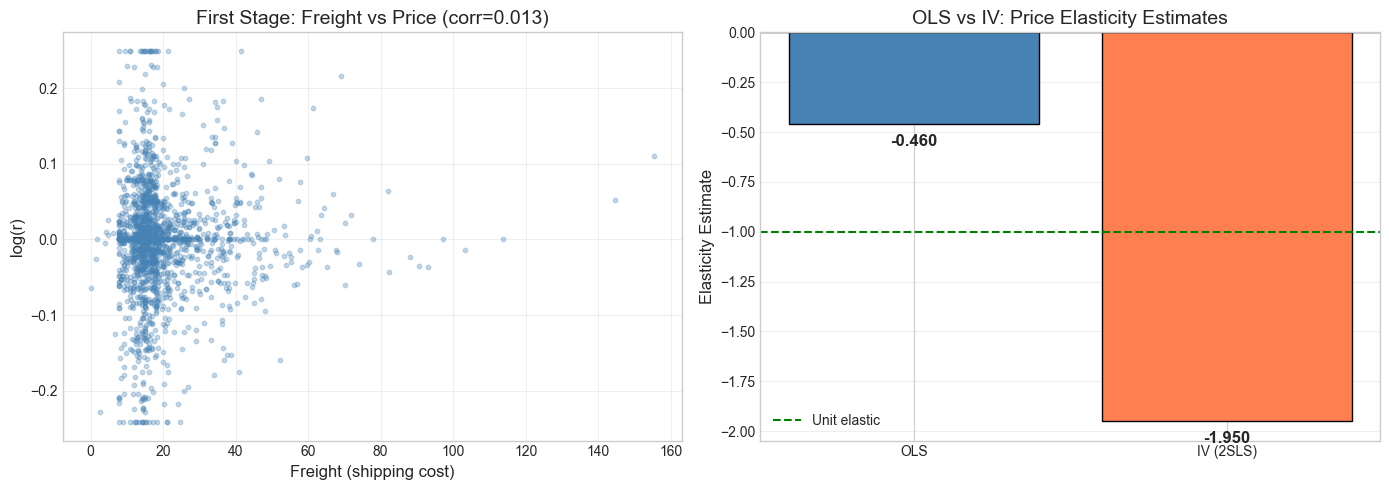

Saved: ../docs/figures/iv_comparison.png


In [14]:
# Visualization: OLS vs IV comparison
if HAS_LINEARMODELS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # First stage visualization
    ax = axes[0]
    sample = iv_data.sample(min(2000, len(iv_data)), random_state=42)
    ax.scatter(sample["freight_mean"], sample["log_r"], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel('Freight (shipping cost)', fontsize=12)
    ax.set_ylabel('log(r)', fontsize=12)
    ax.set_title(f'First Stage: Freight vs Price (corr={corr_freight_logr:.3f})', fontsize=14)
    ax.grid(alpha=0.3)
    
    # OLS vs IV coefficients
    ax = axes[1]
    methods = ['OLS', 'IV (2SLS)']
    elasticities = [ols_model.params['log_r'], second_stage.params['log_r_hat']]
    colors = ['steelblue', 'coral']
    
    bars = ax.bar(methods, elasticities, color=colors, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axhline(y=-1, color='green', linestyle='--', linewidth=1.5, label='Unit elastic')
    
    # Add value labels
    for bar, val in zip(bars, elasticities):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
                f'{val:.3f}', ha='center', va='top', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Elasticity Estimate', fontsize=12)
    ax.set_title('OLS vs IV: Price Elasticity Estimates', fontsize=14)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "iv_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {FIGURES_DIR / 'iv_comparison.png'}")

## 2.4 Limitations of IV Approach

In [15]:
print("=" * 60)
print("LIMITATIONS OF THE IV APPROACH")
print("=" * 60)

print("""
1. EXCLUSION RESTRICTION MAY BE VIOLATED:
   - Freight costs may affect delivery time
   - Delivery time affects customer satisfaction and demand
   - Thus: freight -> delivery_time -> demand (violation)

2. WEAK INSTRUMENT CONCERNS:
   - If freight has low correlation with price, IV estimates are biased
   - Rule of thumb: First-stage F > 10

3. LOCAL AVERAGE TREATMENT EFFECT (LATE):
   - IV estimates elasticity only for price changes induced by freight
   - May differ from average elasticity across all price changes

4. MEASUREMENT:
   - freight_mean is weekly average, may have measurement error
   - Product-level variation in freight may be limited
""")

# Check freight variation
freight_stats = iv_data.groupby("product_id")["freight_mean"].agg(["mean", "std", "min", "max"])
freight_stats["range"] = freight_stats["max"] - freight_stats["min"]
freight_stats["cv"] = freight_stats["std"] / freight_stats["mean"]

print("\n--- Freight Variation Statistics ---")
print(f"Mean within-product CV:     {freight_stats['cv'].mean():.3f}")
print(f"Median within-product CV:   {freight_stats['cv'].median():.3f}")
print(f"Mean within-product range:  {freight_stats['range'].mean():.2f}")

LIMITATIONS OF THE IV APPROACH

1. EXCLUSION RESTRICTION MAY BE VIOLATED:
   - Freight costs may affect delivery time
   - Delivery time affects customer satisfaction and demand
   - Thus: freight -> delivery_time -> demand (violation)

2. WEAK INSTRUMENT CONCERNS:
   - If freight has low correlation with price, IV estimates are biased
   - Rule of thumb: First-stage F > 10

3. LOCAL AVERAGE TREATMENT EFFECT (LATE):
   - IV estimates elasticity only for price changes induced by freight
   - May differ from average elasticity across all price changes

4. MEASUREMENT:
   - freight_mean is weekly average, may have measurement error
   - Product-level variation in freight may be limited


--- Freight Variation Statistics ---
Mean within-product CV:     0.266
Median within-product CV:   0.250
Mean within-product range:  14.76


---
# Part 3: Summary and Conclusions

In [16]:
# Create summary table
print("=" * 60)
print("SUMMARY OF DIAGNOSTICS")
print("=" * 60)

summary_data = []

# Price variation metrics
summary_data.append({
    "Problem": "Price Variation",
    "Indicator": "Median price_span (usable train r_clipped)",
    "Value": f"{elasticity_df['price_span'].median():.3f}",
    "Interpretation": "Limited variation"
})

summary_data.append({
    "Problem": "Price Variation",
    "Indicator": "% usable products span > 20%",
    "Value": f"{(elasticity_df['price_span'] > 0.20).mean()*100:.1f}%",
    "Interpretation": "Minority have adequate variation"
})

summary_data.append({
    "Problem": "Price Variation",
    "Indicator": "Within/Total variance ratio (train avg_price)",
    "Value": f"{within_share_pct:.1f}%",
    "Interpretation": "Low within-product variation (weighted SS decomposition)"
})

# Endogeneity metrics
summary_data.append({
    "Problem": "Endogeneity",
    "Indicator": "Corr(demand_lag, r)",
    "Value": f"{corr_lag1_r:.4f}",
    "Interpretation": "Positive suggests endogeneity" if corr_lag1_r > 0 else "Negative"
})

summary_data.append({
    "Problem": "Endogeneity",
    "Indicator": "% positive elasticities",
    "Value": f"{pct_positive:.1f}%",
    "Interpretation": "High (wrong economic sign)"
})

if HAS_LINEARMODELS:
    summary_data.append({
        "Problem": "IV Analysis",
        "Indicator": "First-stage F",
        "Value": f"{f_stat:.1f}",
        "Interpretation": "Strong" if f_stat > 10 else "Weak"
    })
    
    summary_data.append({
        "Problem": "IV Analysis",
        "Indicator": "OLS elasticity",
        "Value": f"{ols_model.params['log_r']:.3f}",
        "Interpretation": ""
    })
    
    summary_data.append({
        "Problem": "IV Analysis",
        "Indicator": "IV elasticity",
        "Value": f"{second_stage.params['log_r_hat']:.3f}",
        "Interpretation": "More negative suggests attenuation"
    })
    
    summary_data.append({
        "Problem": "IV Analysis",
        "Indicator": "Hausman test p-value",
        "Value": f"{resid_pval:.4f}",
        "Interpretation": "Evidence of endogeneity" if resid_pval < 0.05 else "No evidence"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save summary table
summary_df.to_csv(TABLES_DIR / "elasticity_diagnostics_summary.csv", index=False)
print(f"\nSaved: {TABLES_DIR / 'elasticity_diagnostics_summary.csv'}")

SUMMARY OF DIAGNOSTICS

        Problem                                     Indicator   Value                                           Interpretation
Price Variation    Median price_span (usable train r_clipped)   0.166                                        Limited variation
Price Variation                  % usable products span > 20%   40.5%                         Minority have adequate variation
Price Variation Within/Total variance ratio (train avg_price)    1.0% Low within-product variation (weighted SS decomposition)
    Endogeneity                           Corr(demand_lag, r) -0.0483                                                 Negative
    Endogeneity                       % positive elasticities   36.0%                               High (wrong economic sign)
    IV Analysis                                 First-stage F    14.2                                                   Strong
    IV Analysis                                OLS elasticity  -0.460                  

In [17]:
# Write summary markdown file
md_content = f"""# Elasticity Identification Diagnostics: Summary

## Overview

This analysis investigates why elasticity estimates are lower than expected (median -0.27 for per-product log-log, vs typical retail -1 to -3). Two potential issues were examined:

1. **Limited price variation**: Prices don't vary enough within products
2. **Endogeneity**: Sellers adjust prices based on demand conditions

---

## Key Findings

### 1. Price Variation

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Median price span (usable products, train, `r_clipped`) | {elasticity_df['price_span'].median():.1%} | Limited variation |
| % usable products with span > 20% | {(elasticity_df['price_span'] > 0.20).mean()*100:.1f}% | Minority have adequate variation |
| Within/Total variance (usable products, train, weekly `avg_price`) | {within_share_pct:.1f}% | Most variation is between-product |

**Implication**: With only ~{elasticity_df['price_span'].median()*100:.0f}% median price variation, elasticity estimates are imprecise and sensitive to noise.

The variance ratio above is computed with a weighted ANOVA sum-of-squares decomposition of weekly `avg_price` in the usable training panel. The previously reported 112.9% figure was an artifact of an invalid unweighted decomposition and should not be used.

### 2. Endogeneity

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Corr(demand_lag, price) | {corr_lag1_r:.3f} | {'Positive - suggests reverse causality' if corr_lag1_r > 0 else 'Negative'} |
| % positive elasticities | {pct_positive:.1f}% | High - economically implausible |
"""

if HAS_LINEARMODELS:
    md_content += f"""
### 3. IV Analysis (Freight as Instrument)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| First-stage F | {f_stat:.1f} | {'Strong instrument' if f_stat > 10 else 'Weak instrument'} |
| OLS elasticity | {ols_model.params['log_r']:.3f} | Biased estimate |
| IV elasticity | {second_stage.params['log_r_hat']:.3f} | Less biased (if valid) |
| Hausman p-value | {resid_pval:.4f} | {'Evidence of endogeneity' if resid_pval < 0.05 else 'No strong evidence'} |

**Caveat**: The exclusion restriction may be violated (freight affects delivery time, which affects demand).
"""

md_content += f"""
---

## Implications for the Thesis

1. **Elasticity estimates should be interpreted as lower bounds** due to:
   - Attenuation from measurement error with limited price variation
   - Potential positive bias from endogeneity (sellers raising prices when demand is high)

2. **The two-head neural network may partially mitigate these issues** by:
   - Pooling information across products (borrowing strength)
   - Controlling for time-varying demand factors through the context encoder

3. **Recommendations for Discussion section**:
   - Acknowledge limited within-product price variation as a data limitation
   - Note that elasticity estimates may understate true price sensitivity
   - Suggest future work with experimental price variation or richer instruments

---

## Figures

- `docs/figures/price_span_distribution.png` - Distribution of within-product price variation
- `docs/figures/price_span_vs_elasticity.png` - Relationship between variation and estimates
- `docs/figures/endogeneity_lag_price.png` - Evidence of reverse causality
- `docs/figures/iv_comparison.png` - OLS vs IV estimates
"""

# Write to file
(DOCS_DIR / "elasticity_diagnostics.md").write_text(md_content, encoding="utf-8")
print(f"Saved: {DOCS_DIR / 'elasticity_diagnostics.md'}")

Saved: ../docs/elasticity_diagnostics.md


In [18]:
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

print("\n### Files Created:")
print(f"  - {TABLES_DIR / 'elasticity_diagnostics_summary.csv'}")
print(f"  - {DOCS_DIR / 'elasticity_diagnostics.md'}")
print(f"  - {FIGURES_DIR / 'price_span_distribution.png'}")
print(f"  - {FIGURES_DIR / 'price_span_vs_elasticity.png'}")
print(f"  - {FIGURES_DIR / 'price_span_by_category.png'}")
print(f"  - {FIGURES_DIR / 'quality_by_price_span.png'}")
print(f"  - {FIGURES_DIR / 'endogeneity_lag_price.png'}")
if HAS_LINEARMODELS:
    print(f"  - {FIGURES_DIR / 'iv_comparison.png'}")

print("\n### Key Takeaways:")
print(f"  1. Limited price variation: median span = {elasticity_df['price_span'].median():.1%}")
print(f"  2. {pct_positive:.1f}% of products have wrong-sign elasticity")
print(f"  3. Elasticity estimates are likely lower bounds")


ANALYSIS COMPLETE

### Files Created:
  - ../tables/elasticity_diagnostics_summary.csv
  - ../docs/elasticity_diagnostics.md
  - ../docs/figures/price_span_distribution.png
  - ../docs/figures/price_span_vs_elasticity.png
  - ../docs/figures/price_span_by_category.png
  - ../docs/figures/quality_by_price_span.png
  - ../docs/figures/endogeneity_lag_price.png
  - ../docs/figures/iv_comparison.png

### Key Takeaways:
  1. Limited price variation: median span = 16.6%
  2. 36.0% of products have wrong-sign elasticity
  3. Elasticity estimates are likely lower bounds
